In [2]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  

c:\Users\Public\workspace\sh-wave-ml-surrogate


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

In [9]:
from physics.parameter_sampler import sample_parameters
from physics.dispersion_solver import solve_phase_velocity
from ml.models import get_gbr


In [10]:
X = sample_parameters(n_samples=2000)

In [11]:
y = np.array([solve_phase_velocity(*row) for row in X])

In [12]:

X_scaled = StandardScaler().fit_transform(X)

Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=0.2)

model = get_gbr()
model.fit(Xtr, ytr)

model.score(Xte, yte)


0.5390002087208269

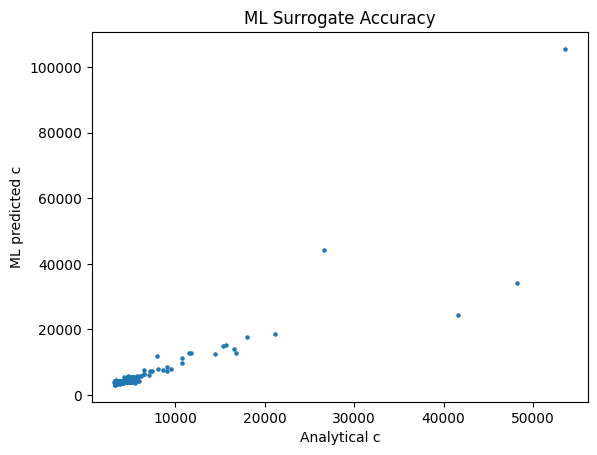

In [13]:
import matplotlib.pyplot as plt

pred = model.predict(Xte)

plt.scatter(yte, pred, s=5)
plt.xlabel("Analytical c")
plt.ylabel("ML predicted c")
plt.title("ML Surrogate Accuracy")
plt.show()


In [15]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: c:\Users\Public\workspace\sh-wave-ml-surrogate\notebooks


In [16]:
import os
from joblib import dump

ROOT = os.path.abspath("..")

model_path = os.path.join(ROOT, "data", "models", "gbr_model.pkl")
os.makedirs(os.path.dirname(model_path), exist_ok=True)

dump(model, model_path)

print("Saved at:", model_path)

Saved at: c:\Users\Public\workspace\sh-wave-ml-surrogate\data\models\gbr_model.pkl
